In [ ]:
#Standard library
import re
import warnings
warnings.filterwarnings('ignore')

#Data manipulation
import pandas as pd
import numpy as np

#NLP
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

#Hugging Face Transformers
from transformers import pipeline
import torch

#Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

#Progress tracking
from tqdm import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
plt.rcParams.update({
    'figure.dpi':       150,
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#e6edf3',
    'ytick.color':      '#e6edf3',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
})

In [ ]:
DEVICE = 0 if torch.cuda.is_available() else -1
device_label = "GPU (CUDA)" if DEVICE == 0 else "CPU"
print(f"Libraries loaded successfully.")
print(f"Inference device: {device_label}")
print(f"PyTorch version  : {torch.__version__}")

Libraries loaded successfully.
Inference device: CPU
PyTorch version  : 2.11.0+cpu


### Load the 'Tweets.csv' dataset

In [ ]:
tweets = pd.read_csv('/content/drive/MyDrive/Tweets.csv')
tweets.head()

,tweetId,url,content,likeCount,retweetCount,replyCount,quoteCount,viewCount,createdAt
0,2033963477765685712,https://x.com/iFixit/status/2033963477765685712,The new MacBook Neo is the most repairable Mac...,3974,368,45,46,220429,"March 17, 2026 at 05:47 PM"
1,2035491410510770591,https://x.com/bp_A16/status/2035491410510770591,春休みですね🥰\n\niPhone17e\nMacBook NEO\n\n2名様にプレゼント...,317,309,111,4,9903,"March 21, 2026 at 10:59 PM"
2,2033536721086795861,https://x.com/MKBHD/status/2033536721086795861,AirPods Max 2\n- Same design\n- 1.5x stronger ...,21239,634,568,221,1834185,"March 16, 2026 at 01:31 PM"
3,2029216468588782066,https://x.com/gregjoz/status/2029216468588782066,"MacBook Neo is new, exciting, original, and HE...",3821,354,117,62,375304,"March 4, 2026 at 03:24 PM"
4,2034405809690394653,https://x.com/mweinbach/status/203440580969039...,Microsoft has the perfect MacBook Neo competit...,2067,52,149,8,283186,"March 18, 2026 at 11:05 PM"


In [ ]:
COLUMN_MAP = {
    'tweet_id':  'tweetId',
    'text':      'content',
    'timestamp': 'createdAt',
}

missing = [v for v in COLUMN_MAP.values() if v not in tweets.columns]
if missing:
    raise ValueError(
        f"Missing columns in CSV: {missing}\n"
        f"Available columns: {tweets.columns.tolist()}"
    )

In [ ]:
df = tweets.rename(columns={v: k for k, v in COLUMN_MAP.items()})

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [ ]:
print(list(COLUMN_MAP.keys()))

['tweet_id', 'text', 'timestamp']


In [ ]:
#data exploration and quality checks

print("═" * 55)
print("DATASET OVERVIEW")
print("═" * 55)
print(f"  Total tweets    : {len(df):,}")
print(f"  Date range      : {df['timestamp'].min():%Y-%m-%d} → {df['timestamp'].max():%Y-%m-%d}")
print(f"  Missing text    : {df['text'].isna().sum():,}")
print(f"  Duplicate tweets: {df.duplicated(subset='tweet_id').sum():,}")
print(f"  Avg tweet length: {df['text'].dropna().str.len().mean():.0f} chars")
print("═" * 55)


df[['tweet_id', 'text', 'timestamp']].head()

═══════════════════════════════════════════════════════
DATASET OVERVIEW
═══════════════════════════════════════════════════════
  Total tweets    : 3,646
  Date range      : 2025-06-30 → 2026-03-29
  Missing text    : 0
  Duplicate tweets: 3,281
  Avg tweet length: 169 chars
═══════════════════════════════════════════════════════


,tweet_id,text,timestamp
0,2033963477765685712,The new MacBook Neo is the most repairable Mac...,2026-03-17 17:47:00
1,2035491410510770591,春休みですね🥰\n\niPhone17e\nMacBook NEO\n\n2名様にプレゼント...,2026-03-21 22:59:00
2,2033536721086795861,AirPods Max 2\n- Same design\n- 1.5x stronger ...,2026-03-16 13:31:00
3,2029216468588782066,"MacBook Neo is new, exciting, original, and HE...",2026-03-04 15:24:00
4,2034405809690394653,Microsoft has the perfect MacBook Neo competit...,2026-03-18 23:05:00


In [ ]:
# Define the tweet text cleaning function

def clean_tweet(text: str) -> str:

    #return empty string for NaN / None
    if not isinstance(text, str) or not text.strip():
        return ''

    #Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    #Remove RT @user: retweet notation
    text = re.sub(r'^RT\s@\w+:\s*', '', text, flags=re.IGNORECASE)

    #Remove @mentions
    text = re.sub(r'@\w+', '', text)

    #Remove '#' but keep the word following it
    text = re.sub(r'#', '', text)

    #Remove non-ASCII characters (emojis, unicode symbols, CJK, etc.)
    text = text.encode('ascii', 'ignore').decode('ascii')

    #Remove digits
    text = re.sub(r'\d+', '', text)

    #Remove punctuation and special characters; keep only letters and spaces
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'_', ' ', text)

    #Collapse multiple whitespace characters into one
    text = re.sub(r'\s+', ' ', text)

    #Strip edges and lowercase
    return text.strip().lower()

tweets.head()

,tweetId,url,content,likeCount,retweetCount,replyCount,quoteCount,viewCount,createdAt
0,2033963477765685712,https://x.com/iFixit/status/2033963477765685712,The new MacBook Neo is the most repairable Mac...,3974,368,45,46,220429,"March 17, 2026 at 05:47 PM"
1,2035491410510770591,https://x.com/bp_A16/status/2035491410510770591,春休みですね🥰\n\niPhone17e\nMacBook NEO\n\n2名様にプレゼント...,317,309,111,4,9903,"March 21, 2026 at 10:59 PM"
2,2033536721086795861,https://x.com/MKBHD/status/2033536721086795861,AirPods Max 2\n- Same design\n- 1.5x stronger ...,21239,634,568,221,1834185,"March 16, 2026 at 01:31 PM"
3,2029216468588782066,https://x.com/gregjoz/status/2029216468588782066,"MacBook Neo is new, exciting, original, and HE...",3821,354,117,62,375304,"March 4, 2026 at 03:24 PM"
4,2034405809690394653,https://x.com/mweinbach/status/203440580969039...,Microsoft has the perfect MacBook Neo competit...,2067,52,149,8,283186,"March 18, 2026 at 11:05 PM"


In [ ]:
df['cleaned_text'] = df['text'].apply(clean_tweet)

#Remove rows where cleaning produced an empty string
n_before = len(df)
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)
n_after  = len(df)

print(f"Rows before : {n_before:,}")
print(f"Rows after  : {n_after:,}  ({n_before - n_after:,} empty rows removed)")

Rows before : 3,646
Rows after  : 3,642  (4 empty rows removed)


In [ ]:
#Sanity check — before / after comparison (3 samples)

print("Before / After comparison (3 samples):")
sample_cols = df[['text', 'cleaned_text']].head(3).copy()
sample_cols.columns = ['Original', 'Cleaned']
for i, row in sample_cols.iterrows():
    print(f"\n[{i+1}] ORIGINAL : {row['Original'][:120]}")
    print(f"    CLEANED  : {row['Cleaned'][:120]}")

Before / After comparison (3 samples):

[1] ORIGINAL : The new MacBook Neo is the most repairable MacBook we’ve seen in 14 years. Screwed-in battery tray, modular ports, sensi
    CLEANED  : the new macbook neo is the most repairable macbook weve seen in years screwedin battery tray modular ports sensible layo

[2] ORIGINAL : 春休みですね🥰

iPhone17e
MacBook NEO

2名様にプレゼント🎁

参加方法👇
① このアカウントをフォロー
② いいね＆リポスト　

〆切　3月25日まで

希望の商品をコメントで当選確率アップ⤴️⤴️ https:/
    CLEANED  : iphonee macbook neo

[3] ORIGINAL : AirPods Max 2
- Same design
- 1.5x stronger noise cancellation
- New amplifiers
- H2 chip, which enables several things,
    CLEANED  : airpods max same design x stronger noise cancellation new amplifiers h chip which enables several things like live trans


In [ ]:

#Load the pre-trained sentiment model

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

print(f"Loading model: {MODEL_NAME}")
print(f"Device: {'GPU' if DEVICE == 0 else 'CPU'}")
print("(First run downloads ~500 MB — subsequent runs use cache)\n")

sentiment_pipeline = pipeline(
    task='text-classification',
    model=MODEL_NAME,
    device=DEVICE,
    truncation=True,
    max_length=128,
    return_all_scores=False,
)


Loading model: cardiffnlp/twitter-roberta-base-sentiment-latest
Device: CPU
(First run downloads ~500 MB — subsequent runs use cache)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Define batch inference helper function
BATCH_SIZE = 32

def run_sentiment_pipeline(
    texts: list,
    pipe,
    batch_size: int = 32
) -> tuple[list, list]:

    # Validate input — replace any NaN / None with an empty string placeholder
    safe_texts = [
        t if isinstance(t, str) and t.strip() else "[empty]"
        for t in texts
    ]

    labels, scores = [], []
    total_batches  = (len(safe_texts) + batch_size - 1) // batch_size

    # Iterate over mini-batches with a live progress bar
    with tqdm(total=total_batches, desc="Sentiment inference", unit="batch") as pbar:
        for start_idx in range(0, len(safe_texts), batch_size):
            batch = safe_texts[start_idx : start_idx + batch_size]
            try:
                # returns a list of {label, score} dicts
                results = pipe(batch)
                for result in results:
                    # Normalise label strings to Title Case (Positive / Neutral / Negative)
                    raw_label = result['label'].capitalize()
                    # Map cardiffnlp model labels to friendly names
                    label_map = {
                        'Positive': 'Positive',
                        'Neutral':  'Neutral',
                        'Negative': 'Negative',
                        'Label_0':  'Negative',   # Fallback for older model versions
                        'Label_1':  'Neutral',
                        'Label_2':  'Positive',
                    }
                    labels.append(label_map.get(raw_label, raw_label))
                    scores.append(round(result['score'], 4))
            except Exception as e:
                # If an entire batch fails (e.g. CUDA OOM), mark as Unknown
                print(f"\n Batch {start_idx}–{start_idx+batch_size} failed: {e}")
                labels.extend(['Unknown'] * len(batch))
                scores.extend([0.0] * len(batch))
            pbar.update(1)

    return labels, scores

In [ ]:
# Run batch inference on all tweets

tweet_texts = df['text'].tolist()

print(f"Starting inference on {len(tweet_texts):,} tweets (batch size={BATCH_SIZE})...")
predicted_labels, confidence_scores = run_sentiment_pipeline(
    tweet_texts, sentiment_pipeline, batch_size=BATCH_SIZE
)

# Attach results to the DataFrame
df['sentiment']        = predicted_labels
df['confidence_score'] = confidence_scores

Starting inference on 3,642 tweets (batch size=32)...


Sentiment inference: 100%|██████████| 114/114 [13:22<00:00,  7.04s/batch]


In [ ]:
# Inference summary — class counts and confidence stats

print("═" * 45)
print("INFERENCE SUMMARY")
print("═" * 45)
print(df['sentiment'].value_counts().to_string())
print("─" * 30)
print(f"Mean confidence : {df['confidence_score'].mean():.3f}")
print(f"Min  confidence : {df['confidence_score'].min():.3f}")
print(f"Max  confidence : {df['confidence_score'].max():.3f}")

═════════════════════════════════════════════
INFERENCE SUMMARY
═════════════════════════════════════════════
sentiment
Neutral     1989
Positive    1233
Negative     420
──────────────────────────────
Mean confidence : 0.771
Min  confidence : 0.370
Max  confidence : 0.991


In [ ]:
print("Sample predictions (2 per class):")

for sentiment_class in ['Positive', 'Neutral', 'Negative']:
    subset = df[df['sentiment'] == sentiment_class][['text', 'sentiment', 'confidence_score']]
    sample = subset.nlargest(2, 'confidence_score')   # Show high-confidence examples
    print(f"\n{'─'*55}")
    print(f"{sentiment_class.upper()} EXAMPLES")
    print(f"{'─'*55}")
    for _, row in sample.iterrows():
        print(f"  Tweet      : {row['text'][:100]}…")
        print(f"  Confidence : {row['confidence_score']:.4f}")
        print()

Sample predictions (2 per class):

───────────────────────────────────────────────────────
POSITIVE EXAMPLES
───────────────────────────────────────────────────────
  Tweet      : Mac just had its best launch week ever for first-time Mac customers. We love seeing the enthusiasm!…
  Confidence : 0.9911

  Tweet      : Mac just had its best launch week ever for first-time Mac customers. We love seeing the enthusiasm!…
  Confidence : 0.9911


───────────────────────────────────────────────────────
NEUTRAL EXAMPLES
───────────────────────────────────────────────────────
  Tweet      : @RoadsOfMumbai macbook neo?…
  Confidence : 0.9282

  Tweet      : @RoadsOfMumbai macbook neo?…
  Confidence : 0.9282


───────────────────────────────────────────────────────
NEGATIVE EXAMPLES
───────────────────────────────────────────────────────
  Tweet      : MacBook NEO’s display is SO SHIT OMG 😷 https://t.co/Z1uZgVygJR…
  Confidence : 0.9470

  Tweet      : MacBook NEO’s display is SO SHIT OMG 😷 https:

In [ ]:
cOLOURS = {
    'Positive': '#3fb950',   # GitHub Actions green
    'Neutral':  '#8b949e',   # GitHub muted grey
    'Negative': '#f85149',   # GitHub red
}

In [ ]:
sentiment_counts = df['sentiment'].value_counts().reindex(
    ['Positive', 'Neutral', 'Negative'], fill_value=0
)
total         = sentiment_counts.sum()
sentiment_pct = (sentiment_counts / total * 100).round(1)

print("Sentiment counts:")
for s in sentiment_counts.index:
    print(f"   {s:10s}: {sentiment_counts[s]:,}  ({sentiment_pct[s]}%)")

Sentiment counts:
   Positive  : 1,233  (33.9%)
   Neutral   : 1,989  (54.6%)
   Negative  : 420  (11.5%)


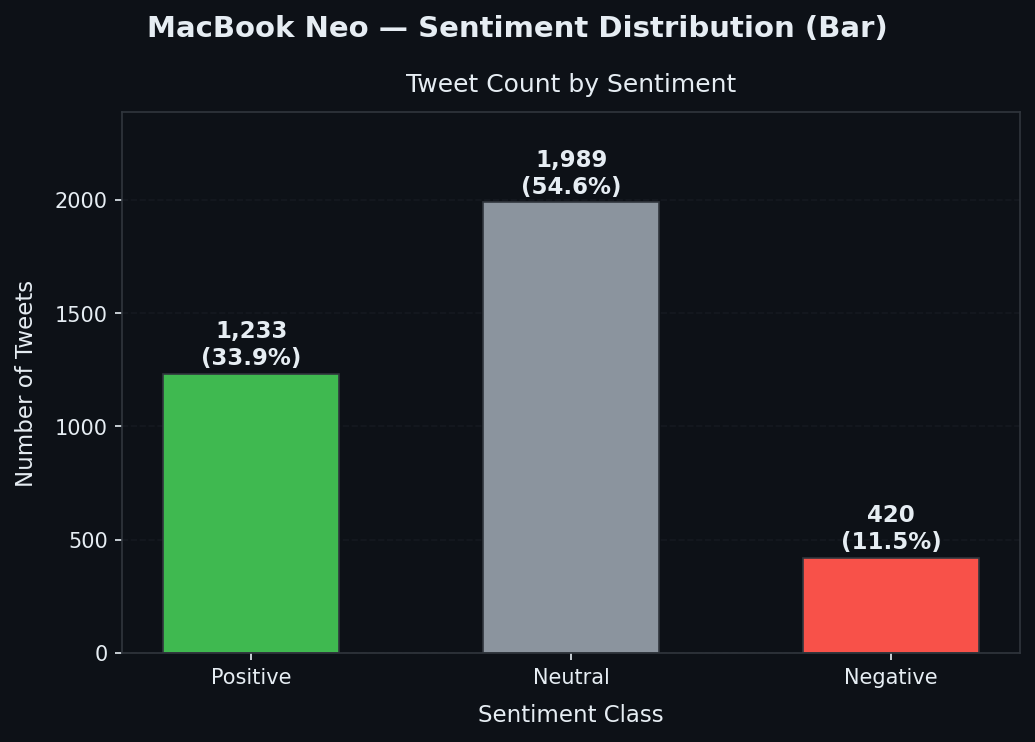

In [ ]:
bar_colours = [cOLOURS[s] for s in sentiment_counts.index]

fig, ax_bar = plt.subplots(figsize=(7, 5))
fig.suptitle(
    "MacBook Neo — Sentiment Distribution (Bar)",
    fontsize=14, fontweight='bold', color='#e6edf3'
)

bars = ax_bar.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=bar_colours,
    edgecolor='#30363d',
    linewidth=0.8,
    width=0.55,
)

for bar, count, pct in zip(bars, sentiment_counts.values, sentiment_pct.values):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f"{count:,}\n({pct}%)",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#e6edf3'
    )

ax_bar.set_title("Tweet Count by Sentiment", fontsize=12, pad=10)
ax_bar.set_xlabel("Sentiment Class", fontsize=11, labelpad=8)
ax_bar.set_ylabel("Number of Tweets",  fontsize=11, labelpad=8)
ax_bar.set_ylim(0, sentiment_counts.max() * 1.20)
ax_bar.yaxis.grid(True, alpha=0.4)
ax_bar.set_axisbelow(True)

plt.tight_layout()
plt.savefig('sentiment_bar_chart.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()

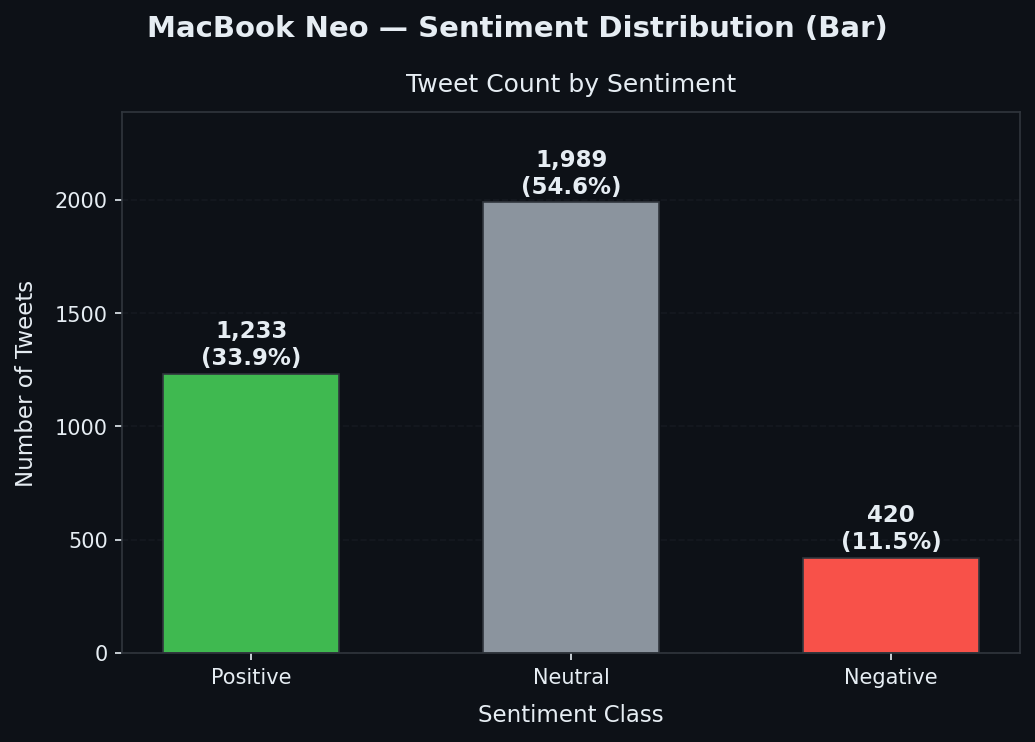

In [ ]:
# Bar chart - Tweet count per sentiment class

bar_colours = [cOLOURS[s] for s in sentiment_counts.index]

fig, ax_bar = plt.subplots(figsize=(7, 5))
fig.suptitle(
    "MacBook Neo — Sentiment Distribution (Bar)",
    fontsize=14, fontweight='bold', color='#e6edf3'
)

bars = ax_bar.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=bar_colours,
    edgecolor='#30363d',
    linewidth=0.8,
    width=0.55,
)

for bar, count, pct in zip(bars, sentiment_counts.values, sentiment_pct.values):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.005,
        f"{count:,}\n({pct}%)",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#e6edf3'
    )

ax_bar.set_title("Tweet Count by Sentiment", fontsize=12, pad=10)
ax_bar.set_xlabel("Sentiment Class", fontsize=11, labelpad=8)
ax_bar.set_ylabel("Number of Tweets",  fontsize=11, labelpad=8)
ax_bar.set_ylim(0, sentiment_counts.max() * 1.20)
ax_bar.yaxis.grid(True, alpha=0.4)
ax_bar.set_axisbelow(True)

plt.tight_layout()
plt.savefig('sentiment_bar_chart.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()

In [ ]:
# Build combined stopword set for word clouds


NLTK_STOPS = set(stopwords.words('english'))
WC_STOPS   = set(STOPWORDS)   # WordCloud's built-in list

# Custom MacBook Neo domain stopwords: brand & product terms that

DOMAIN_STOPS = {
    'macbook', 'neo', 'apple', 'new', 'get', 'one',
    'just', 'like', 'will', 'cant', 'dont', 'its',
    'im', 'ive', 'would', 'could', 'also', 'really',
    'https', 'co', 'rt', 'amp', 'via', 'even',
}

# Merge all stopword sets into one
ALL_STOPS = NLTK_STOPS | WC_STOPS | DOMAIN_STOPS

In [ ]:
def build_word_cloud(text_series: pd.Series, colormap: str, title: str, ax) -> None:

    combined_text = " ".join(text_series.dropna().tolist())

    if not combined_text.strip():
        ax.text(0.5, 0.5, "No text available",
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title(title, fontsize=14, color='#e6edf3')
        return

    wc = WordCloud(
        width=900, height=500,
        background_color='#0d1117',
        colormap=colormap,
        stopwords=ALL_STOPS,
        max_words=120,
        min_font_size=8,
        max_font_size=90,
        collocations=True,
        prefer_horizontal=0.85,
        random_state=42,
    ).generate(combined_text)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', color='#e6edf3', pad=12)



  Positive tweets for cloud : 1,233
  Negative tweets for cloud : 420


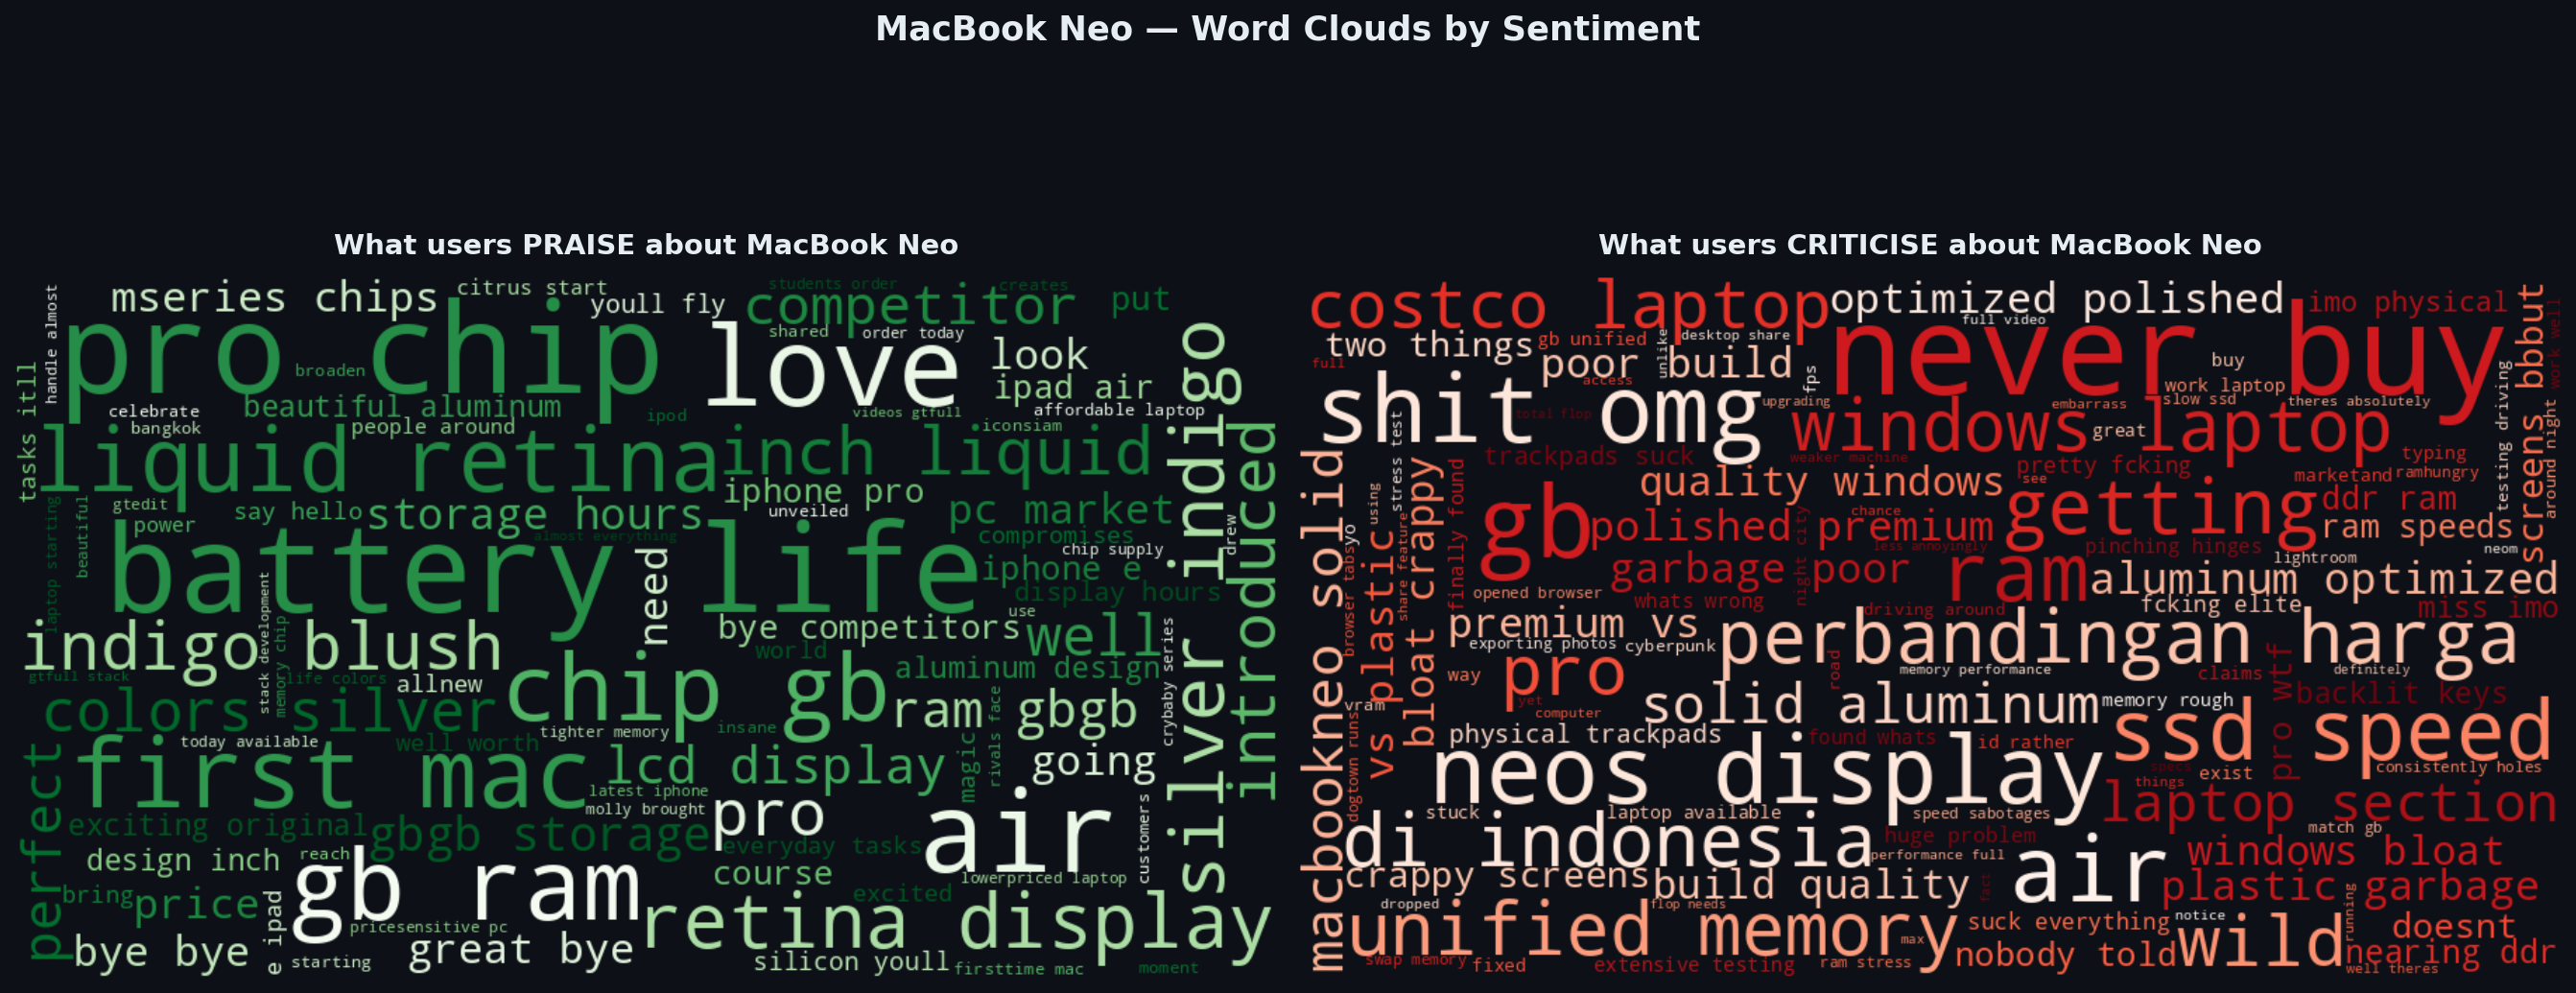

In [ ]:
#Render word clouds - Positive vs Negative tweets

pos_text = df.loc[df['sentiment'] == 'Positive', 'cleaned_text']
neg_text = df.loc[df['sentiment'] == 'Negative', 'cleaned_text']

print(f"  Positive tweets for cloud : {len(pos_text):,}")
print(f"  Negative tweets for cloud : {len(neg_text):,}")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    "MacBook Neo — Word Clouds by Sentiment",
    fontsize=17, fontweight='bold', color='#e6edf3', y=1.01
)

build_word_cloud(
    pos_text,
    colormap='Greens',
    title="What users PRAISE about MacBook Neo",
    ax=axes[0]
)

build_word_cloud(
    neg_text,
    colormap='Reds',
    title="What users CRITICISE about MacBook Neo",
    ax=axes[1]
)

plt.tight_layout()
plt.savefig('wordclouds_sentiment.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()


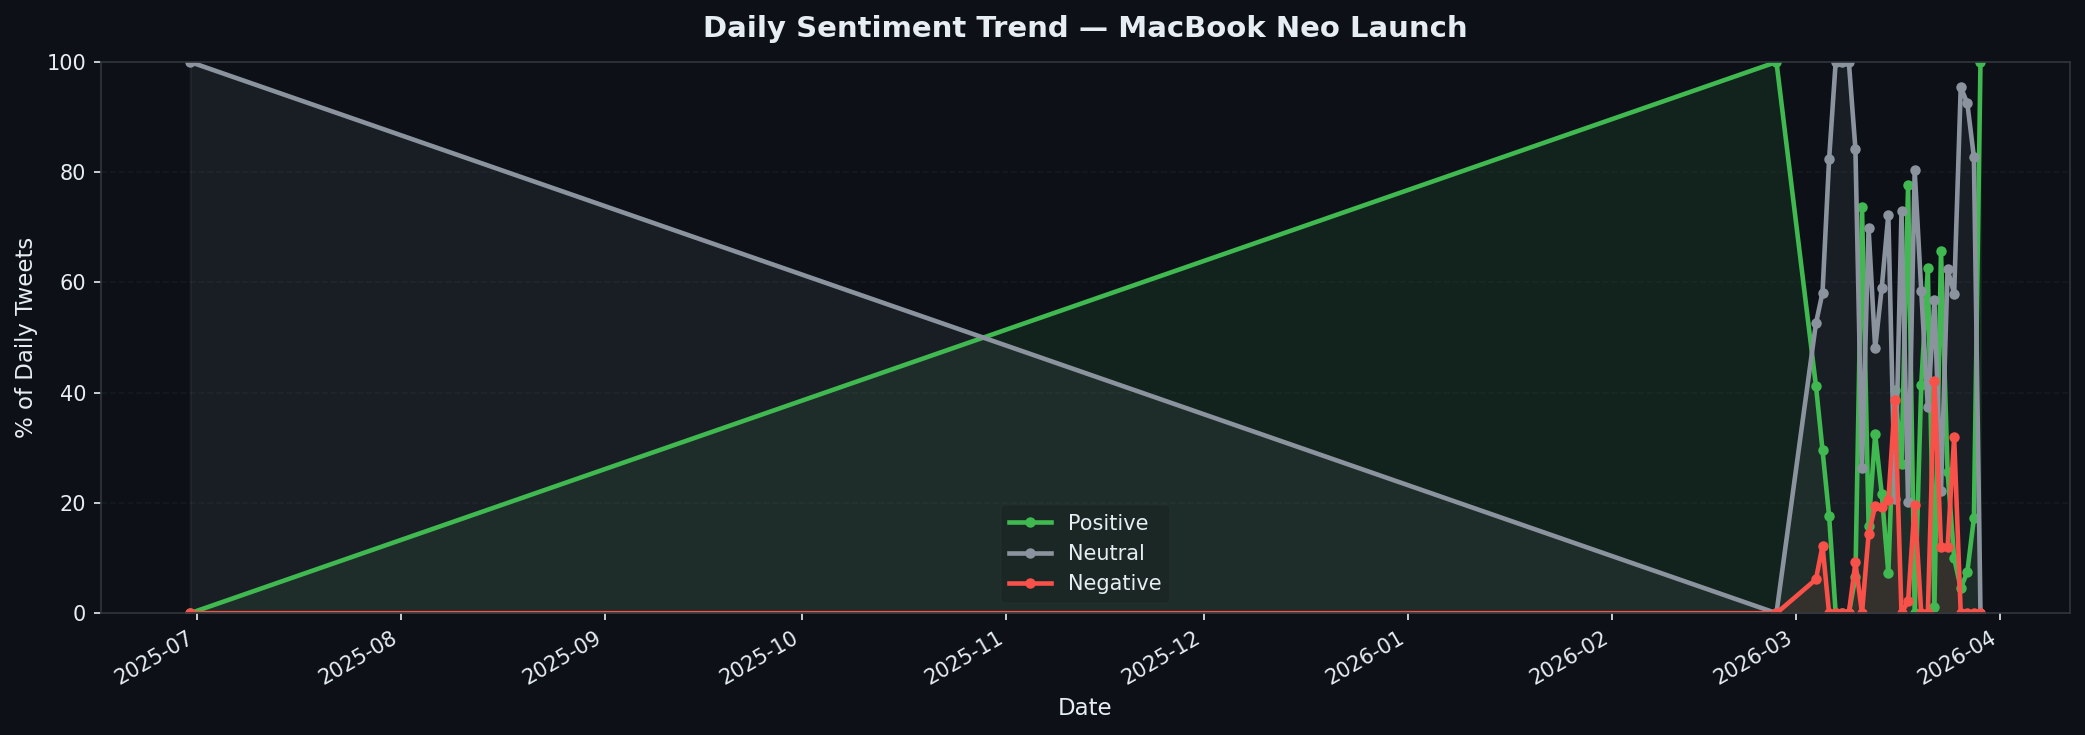

In [ ]:
# Daily sentiment trend line

# Extract date from the parsed timestamp column
df['date'] = df['timestamp'].dt.date

# Pivot: count tweets per (date, sentiment) cell
daily = (
    df.groupby(['date', 'sentiment'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=['Positive', 'Neutral', 'Negative'], fill_value=0)
)

# Convert to row percentages so daily volume differences don't distort the view
daily_pct = daily.div(daily.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))

for sentiment_class, colour in cOLOURS.items():
    if sentiment_class in daily_pct.columns:
        ax.plot(
            daily_pct.index,
            daily_pct[sentiment_class],
            label=sentiment_class,
            color=colour,
            linewidth=2.2,
            marker='o',
            markersize=4,
        )
        ax.fill_between(
            daily_pct.index,
            daily_pct[sentiment_class],
            alpha=0.10,
            color=colour,
        )

ax.set_title("Daily Sentiment Trend — MacBook Neo Launch",
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("% of Daily Tweets", fontsize=11)
ax.legend(fontsize=10, framealpha=0.2, edgecolor='#30363d')
ax.set_ylim(0, 100)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('sentiment_trend.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()

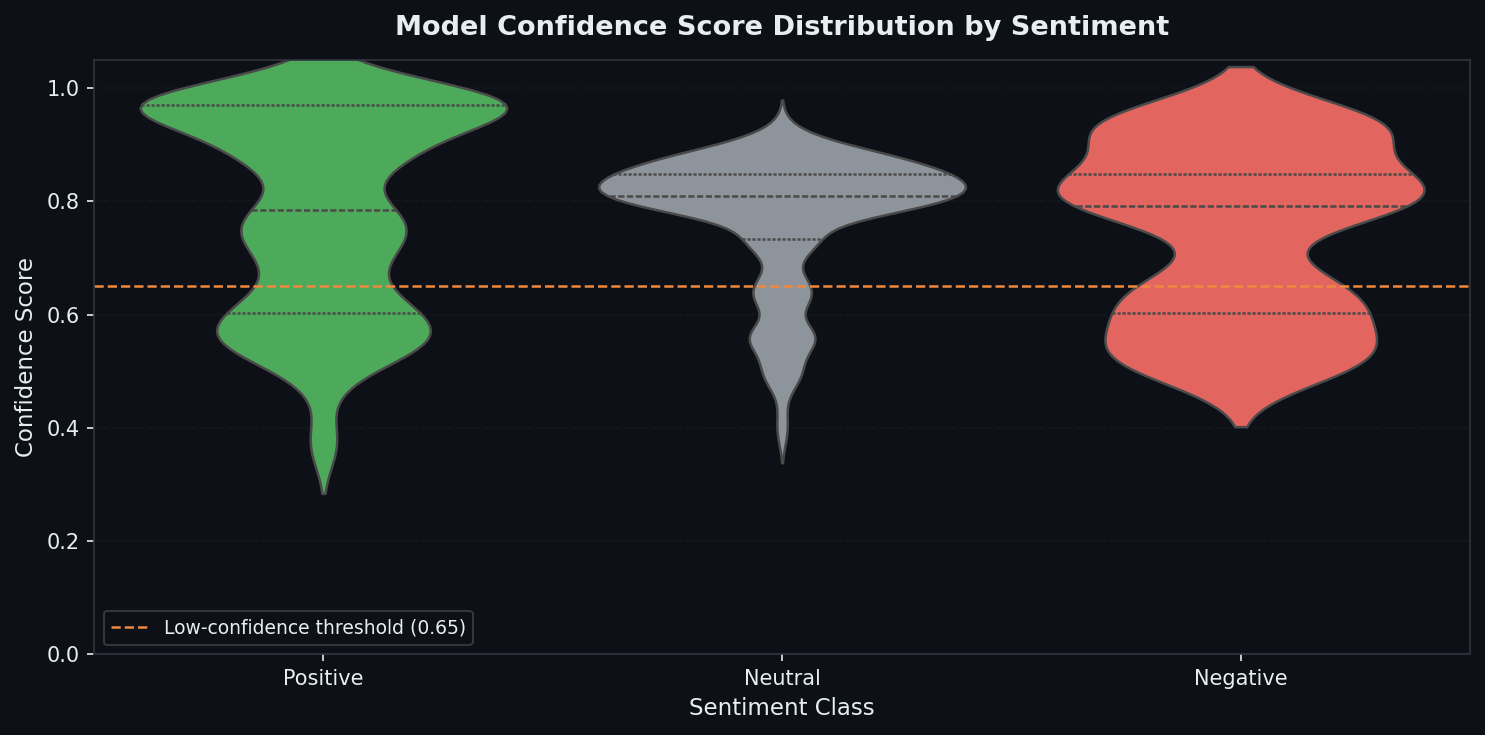

In [ ]:
# Confidence score distribution - violin plot

fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=df,
    x='sentiment',
    y='confidence_score',
    order=['Positive', 'Neutral', 'Negative'],
    palette=list(cOLOURS.values()),
    inner='quartile',      # Show Q1, median, Q3 lines inside each violin
    linewidth=1.2,
    ax=ax,
)

# Draw a horizontal line at the 0.65 low-confidence threshold
ax.axhline(0.65, color='#f0883e', linestyle='--', linewidth=1.2,
           label='Low-confidence threshold (0.65)')

ax.set_title("Model Confidence Score Distribution by Sentiment",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Sentiment Class", fontsize=11)
ax.set_ylabel("Confidence Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, framealpha=0.2)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('confidence_distribution.png', bbox_inches='tight', facecolor='#0d1117', dpi=150)
plt.show()

In [ ]:
#Flag low-confidence predictions for review


low_conf = df[df['confidence_score'] < 0.65]
print(f"Low-confidence predictions (<0.65): {len(low_conf):,}  "
      f"({len(low_conf)/len(df)*100:.1f}% of total)")
print("   Consider manual review or ensemble voting for these rows.")
print()

# Preview a few low-confidence cases
if len(low_conf) > 0:
    print("Sample low-confidence predictions:")
    sample_lc = low_conf[['text', 'sentiment', 'confidence_score']].head(5)
    for _, row in sample_lc.iterrows():
        print(f"  [{row['sentiment']:8s} | {row['confidence_score']:.3f}] {row['text'][:90]}…")

Low-confidence predictions (<0.65): 878  (24.1% of total)
   Consider manual review or ensemble voting for these rows.

Sample low-confidence predictions:
  [Positive | 0.502] 春休みですね🥰

iPhone17e
MacBook NEO

2名様にプレゼント🎁

参加方法👇
① このアカウントをフォロー
② いいね＆リポスト　

〆切　3月25日まで

…
  [Positive | 0.586] AirPods Max 2
- Same design
- 1.5x stronger noise cancellation
- New amplifiers
- H2 chip,…
  [Positive | 0.545] Microsoft has the perfect MacBook Neo competitor with the Surface Laptop 13 but it's just …
  [Positive | 0.627] Hardwarecanucks actually did it!

Opening 56 apps
Legion Laptop vs MacBook Neo https://t.c…
  [Neutral  | 0.489] apple just dropped the macbook neo

- starts at $599
- powered by the a18 pro chip
- 13" l…


In [ ]:
# Prepare the final output DataFrame


OUTPUT_FILENAME = 'macbook_neo_sentiment_results.csv'

# Select and re-order the final columns for the output file
output_columns = [
    'tweet_id',          # Unique tweet ID
    'text',              # Original raw tweet text
    'cleaned_text',      # Preprocessed text (for word analysis)
    'timestamp',         # Post datetime
    'date',              # Derived date (YYYY-MM-DD)
    'sentiment',         # ← NEW: predicted sentiment class
    'confidence_score',  # ← NEW: model confidence (0-1)
]

# Include any engagement columns that exist in the source data
optional_cols = ['likeCount', 'retweetCount', 'replyCount', 'quoteCount', 'viewCount']
for col in optional_cols:
    if col in df.columns:
        output_columns.append(col)

# Build the final output DataFrame (keep only columns that exist)
output_cols_present = [c for c in output_columns if c in df.columns]
df_output = df[output_cols_present].copy()

print(f"Output DataFrame prepared.")
print(f"Rows    : {len(df_output):,}")
print(f"Columns : {output_cols_present}")

Output DataFrame prepared.
Rows    : 3,642
Columns : ['tweet_id', 'text', 'cleaned_text', 'timestamp', 'date', 'sentiment', 'confidence_score', 'likeCount', 'retweetCount', 'replyCount', 'quoteCount', 'viewCount']


In [ ]:
# export summary


print("═" * 55)
print("EXPORT SUMMARY")
print("═" * 55)
print(f"  Output file     : {OUTPUT_FILENAME}")
print(f"  Total rows      : {len(df_output):,}")
print(f"  Columns exported: {len(output_cols_present)}")
print(f"  Positive tweets : {(df_output['sentiment']=='Positive').sum():,}")
print(f"  Neutral  tweets : {(df_output['sentiment']=='Neutral').sum():,}")
print(f"  Negative tweets : {(df_output['sentiment']=='Negative').sum():,}")
print(f"  Avg confidence  : {df_output['confidence_score'].mean():.4f}")
print("═" * 55)

═══════════════════════════════════════════════════════
EXPORT SUMMARY
═══════════════════════════════════════════════════════
  Output file     : macbook_neo_sentiment_results.csv
  Total rows      : 3,642
  Columns exported: 12
  Positive tweets : 1,233
  Neutral  tweets : 1,989
  Negative tweets : 420
  Avg confidence  : 0.7714
═══════════════════════════════════════════════════════


In [ ]:
# Save enriched CSV to disk (UTF-8 with BOM for Excel)

df_output.to_csv(OUTPUT_FILENAME, index=False, encoding='utf-8-sig')


In [ ]:
from google.colab import files

# Download the CSV to local machine

files.download(OUTPUT_FILENAME)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Download all saved chart images

charts_to_download = [
    'sentiment_bar_chart.png',
    'sentiment_pie_chart.png',
    'wordclouds_sentiment.png',
    'sentiment_trend.png',
    'confidence_distribution.png',
]

for chart in charts_to_download:
    try:
        files.download(chart)
        print(f"Downloaded: {chart}")
    except Exception as e:
        print(f"Could not download {chart}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: sentiment_bar_chart.png
Could not download sentiment_pie_chart.png: Cannot find file: sentiment_pie_chart.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: sentiment_trend.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: confidence_distribution.png
